# Latency Comparison

## Goal
Measure how long the model takes to respond under different conditions.
Latency is a critical metric in production systems.

## What We Measure
- Response time for short vs long prompts
- Response time for simple vs complex questions
- Consistency of latency across multiple runs

## Key Question
Does prompt length or question complexity affect response time?

In [2]:
import requests
import time
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## 1. Define Test Cases

In [3]:
# Short context
short_context = "The Eiffel Tower is 330 meters tall and located in Paris."

# Long context
long_context = """
The Eiffel Tower was built between 1887 and 1889.
It is located in Paris, France, on the Champ de Mars.
The tower is 330 meters tall including its antenna.
It was designed by Gustave Eiffel and his engineering company.
The tower was originally intended to be a temporary structure
and was almost demolished in 1909.
It receives approximately 7 million visitors per year.
The tower has three levels accessible to visitors.
The first floor is at 57 meters, the second at 115 meters,
and the top floor is at 276 meters above ground.
The structure weighs approximately 7,300 tons.
"""

test_cases = [
    {"name": "Short context, simple question", "context": short_context, "question": "How tall is the Eiffel Tower?"},
    {"name": "Long context, simple question", "context": long_context, "question": "How tall is the Eiffel Tower?"},
    {"name": "Short context, complex question", "context": short_context, "question": "Explain the significance of the Eiffel Tower's height in detail."},
    {"name": "Long context, complex question", "context": long_context, "question": "Summarize all the key facts about the Eiffel Tower mentioned in the context."},
]

print(f"Total test cases: {len(test_cases)}")
for tc in test_cases:
    print(f"- {tc['name']}")

Total test cases: 4
- Short context, simple question
- Long context, simple question
- Short context, complex question
- Long context, complex question


## 2. Measure Latency
Each test runs 3 times to get average latency.

In [8]:
def query_with_latency(question: str, context: str) -> dict:
    """Query model and measure response time."""
    prompt = f"Context: {context}\nQuestion: {question}\nAnswer:"

    start = time.time()
    response = requests.post(
        "http://127.0.0.1:11434/api/chat",
        json={
            "model": "gemma3:12b",
            "messages": [{"role": "user", "content": prompt}],
            "stream": False
        },
        proxies={"http": None, "https": None}
    )
    elapsed = time.time() - start

    return {
        "response": response.json()["message"]["content"],
        "latency": elapsed
    }

# Run each test case 3 times
RUNS = 3
results = []

print("Measuring latency...")
for tc in test_cases:
    latencies = []
    for run in range(RUNS):
        result = query_with_latency(tc["question"], tc["context"])
        latencies.append(result["latency"])
        print(f"[{tc["name"]}] Run {run+1}: {result["latency"]:.2f}s")

    results.append({
        "name": tc["name"],
        "avg_latency": np.mean(latencies),
        "min_latency": np.min(latencies),
        "max_latency": np.max(latencies),
        "std_latency": np.std(latencies)
    })

df = pd.DataFrame(results)
print("\nResults:")
print(df[["name", "avg_latency", "std_latency"]].round(2))

Measuring latency...
[Short context, simple question] Run 1: 0.91s
[Short context, simple question] Run 2: 0.32s
[Short context, simple question] Run 3: 0.32s
[Long context, simple question] Run 1: 0.93s
[Long context, simple question] Run 2: 0.28s
[Long context, simple question] Run 3: 0.29s
[Short context, complex question] Run 1: 29.37s
[Short context, complex question] Run 2: 30.06s
[Short context, complex question] Run 3: 37.51s
[Long context, complex question] Run 1: 6.76s
[Long context, complex question] Run 2: 6.10s
[Long context, complex question] Run 3: 6.14s

Results:
                              name  avg_latency  std_latency
0   Short context, simple question         0.51         0.28
1    Long context, simple question         0.50         0.30
2  Short context, complex question        32.31         3.69
3   Long context, complex question         6.33         0.30


## 3. Visualize Latency

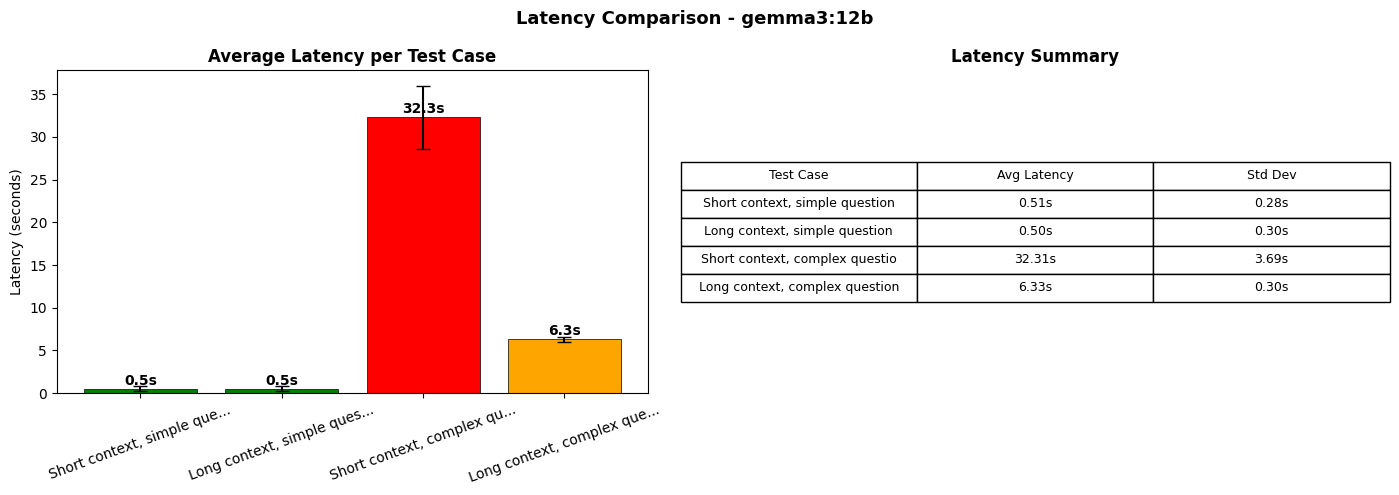

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

short_names = [n[:25] + "..." for n in df["name"]]
colors = ["green" if l < 5 else "orange" if l < 15 else "red" for l in df["avg_latency"]]

# Chart 1 - Average latency
bars = axes[0].bar(short_names, df["avg_latency"], color=colors, edgecolor="black", linewidth=0.5)
axes[0].errorbar(short_names, df["avg_latency"], yerr=df["std_latency"],
                fmt="none", color="black", capsize=5, linewidth=1.5)
axes[0].set_title("Average Latency per Test Case", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Latency (seconds)")
axes[0].tick_params(axis="x", rotation=20)
for bar, val in zip(bars, df["avg_latency"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{val:.1f}s", ha="center", fontweight="bold")

# Chart 2 - Summary table
axes[1].axis("off")
summary = [[row["name"][:30], f"{row["avg_latency"]:.2f}s", f"{row["std_latency"]:.2f}s"]
            for _, row in df.iterrows()]
table = axes[1].table(
    cellText=summary,
    colLabels=["Test Case", "Avg Latency", "Std Dev"],
    cellLoc="center",
    loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 2)
axes[1].set_title("Latency Summary", fontsize=12, fontweight="bold")

plt.suptitle("Latency Comparison - gemma3:12b", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("latency_comparison.png", dpi=300)
plt.show()

## 4. Key Observations

| Test Case | Avg Latency | Insight |
|-----------|-------------|---------|
| Short context, simple question | 0.51s | Fast — model finds answer immediately |
| Long context, simple question | 0.50s | Context length does not affect simple Q |
| Short context, complex question | 32.31s | Slow — model must generate from scratch |
| Long context, complex question | 6.33s | Faster — context guides the generation |

## Key Insight
Question complexity affects latency more than context length.
A complex question with short context forces the model to generate
long responses from its own knowledge — much slower.

A complex question with rich context is faster because
the model can extract and summarize rather than generate.

## Production Implication
In production systems:
- Simple factual Q: < 1s — acceptable for real-time
- Complex generation: 6-32s — needs async handling or streaming

## Next
-> 06_retrieval_evaluation.ipynb